# **Rapid Express: Análisis de Perfil, Desempeño y Absentismo Laboral**
**(Basado en el dataset interno de incidencias de Recursos Humanos)**

---
### **Exploratory Data Analysis (EDA)**

**Analistas:** Emilio, Nuria (Perfil y Desempeño) y Andrea (Absentismo y Bienestar) Ana causa baja

**Objetivo del Análisis:** Comprender qué características sociodemográficas, operativas y de salud de nuestra plantilla están asociadas tanto a un **mejor cumplimiento de objetivos (Hit Target)** como a los **niveles de absentismo**. Esta visión integral nos permitirá diseñar políticas proactivas de selección, capacitación, retención y bienestar corporativo.

### Importación de bibliotecas

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
# Configuración estética para gráficos de nivel profesional
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')# Ocultar advertencias menores para un notebook más limpio

print("Librerías importadas correctamente. Entorno listo.")

Librerías importadas correctamente. Entorno listo.


### Conexión a Base de Datos y Extracción Inicial
Para asegurar que nuestro análisis sea escalable y consuma siempre los datos más actualizados, hemos automatizado la ingesta conectando el entorno directamente al servidor **MySQL** de la compañía en lugar de usar extracciones manuales en CSV.

In [40]:
import mysql.connector
import pandas as pd

config = {
    'host': '212.227.90.6',
    'user': 'Equipo28',
    'password': 'E1q2u3i4p5o28',
    'database': 'Equip_28'
}

conn = mysql.connector.connect(**config)
cursor = conn.cursor()

cursor.execute("SELECT database();")
db_actual = cursor.fetchone()[0]
print(f"--- Conectado a la base de datos: {db_actual} ---")

cursor.execute("SHOW TABLES;")
tablas = cursor.fetchall()

print("Tablas encontradas:")
for t in tablas:
    print(f" -> {t[0]}")
    globals()[t[0]] = pd.read_sql("SELECT * FROM " + t[0], conn)
    
cursor.close()
conn.close()

--- Conectado a la base de datos: Equip_28 ---
Tablas encontradas:
 -> RRHH
 -> RRHH_04052026
 -> RRHH_27042026
 -> vista_duplicados_exactos
 -> vista_duplicados_exactos2


In [41]:
df_RRHH_04052026=RRHH_04052026.copy()

In [42]:
df_RRHH_04052026.shape

(1110, 21)

In [43]:
df_RRHH_04052026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1110 entries, 0 to 1109
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       1110 non-null   int64 
 1   Reason_absence           1110 non-null   int64 
 2   Month_absence            1110 non-null   int64 
 3   Day_week                 1110 non-null   int64 
 4   Seasons                  1110 non-null   int64 
 5   Transportation_expense   1110 non-null   int64 
 6   Distance_Residence_Work  1110 non-null   int64 
 7   Service_time             1110 non-null   int64 
 8   Age                      1110 non-null   int64 
 9   Work_load_Average_day    1110 non-null   object
 10  Hit_target               1110 non-null   int64 
 11  Disciplinary_failure     1110 non-null   object
 12  Education                1110 non-null   object
 13  Son                      1110 non-null   object
 14  Social_drinker           1110 non-null  

In [44]:
df_RRHH_04052026=RRHH_04052026.copy()

In [45]:
# Eliminamos los duplicados exactos detectados previamente
df_clean = df_RRHH_04052026.drop_duplicates().copy()
print(f"Registros tras eliminar duplicados exactos: {df_clean.shape[0]}")

# Consolidamos los datos para tener 1 fila por empleado (Perfil Único)
df_perfil = df_clean.groupby('ID').agg({
    'Age': 'first',
    'Service_time': 'first',
    'Distance_Residence_Work': 'first',
    'Work_load_Average_day': 'first',
    'Transportation_expense': 'first',
    'Education': 'first',
    'Son': 'first',
    'Body_mass_index': 'first',
    'Social_drinker': 'first',
    'Social_smoker': 'first',
    'Disciplinary_failure': 'first',
    'Hit_target': 'mean',          # Promedio de cumplimiento de objetivos
    'Absenteeism_hours': 'sum'     # Suma total de horas de ausencia
}).reset_index()

print(f"Total de empleados únicos a analizar: {df_perfil.shape[0]}")

Registros tras eliminar duplicados exactos: 1056
Total de empleados únicos a analizar: 386


In [46]:
#Despues de eliminar los duplicados exactos, aún nos quedan 5 registros donde el mes de ausencia no se ha registrado
df1=df_RRHH_04052026[df_RRHH_04052026['Month_absence']==0]
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 737 to 1060
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       5 non-null      int64 
 1   Reason_absence           5 non-null      int64 
 2   Month_absence            5 non-null      int64 
 3   Day_week                 5 non-null      int64 
 4   Seasons                  5 non-null      int64 
 5   Transportation_expense   5 non-null      int64 
 6   Distance_Residence_Work  5 non-null      int64 
 7   Service_time             5 non-null      int64 
 8   Age                      5 non-null      int64 
 9   Work_load_Average_day    5 non-null      object
 10  Hit_target               5 non-null      int64 
 11  Disciplinary_failure     5 non-null      object
 12  Education                5 non-null      object
 13  Son                      5 non-null      object
 14  Social_drinker           5 non-null      objec

## Información general del dataset

El conjunto después de eliminar los duplicados exactos contiene **806 registros y 21 columnas** correspondientes a **136 empleados** únicos y los atributos son:  
- **ID** (id):identificación única del empleado
- **reason_absence** (razón de absentismo): razón de la ausencia al trabajo. Ausencias certificadas según la Clasificación Internacional de Enfermedades (CIE o  CID en inglés), estratificadas en 21 categorías, y 7 categorías adicionales sin CIE: seguimiento del paciente (22), consulta médica (23), donación de sangre (24), examen de laboratorio (25), ausencia injustificada (26), fisioterapia (27) y consulta odontológica (28).  CATEGÓRICA
- **month_absence** (mes de absentismo): mes en el que el empleado se ausenta del trabajo .  TEMPORAL
- **Day_week** (dia de la semana): Dia de la semana en que se producce la ausencia.  TEMPORAL
- **Seasons** (estación del año): estación en que se produce la ausencia (Verano (1), Otoño (2), Invierno(3), Primavera (4)). TEMPORAL
- **Transportation_expense** (gastos de transporte): gastos de transporte del empleado.  NUMÉRICA
- **Distance_Residence_Work** (distancia): distancia en km entre la residencia y el lugar de trabajo.  NUMÉRICA
- **Service_time** (antigüedad): tiempo de servicio o antigüedad del empleado en la empresa.  NUMÉRICA
- **Age** (edad): edad del empleado.  NUMÉRICA
- **Work_load_Average_day** (carga media diaria): carga de trabajo promedio por día.  NUMÉRICA
- **Hit_target** (cumplimiento del objetivo de desempeño): indica el porcentage alcanzado del objetivo establecido. NUMÉRICA  
- **Disciplinary_failure** (sanción disciplinaria): indica si el empleado ha tenido sanciones disciplinarias (sí=1/no=0). CATEGÓRICA
- **Education** (nivel educativo): nivel educativo del empleado (Bachillerato (1),graduado (2),postgraduado (3),master/doctorado (4)).  CATEGÓRICA
- **Son** (núm de hijos): Número de hijos.  NUMÉRICA
- **Social_drinker** (consumo de alcohol): indica si el empleado consume alcohol (sí=1/no=0).  CATEGÓRICA
- **Social_smoker** (fumador): indica si el empleado consume tabaco (sí=1/no=0). CATEGÓRICA
- **Pet** (mascotas): indica el número de mascotas del empleado.  NUMÉRICA
- **Weight** (peso): peso del empleado. NUMÉRICA
- **Height** (altura): altura del empleado.  NUMÉRICA
- **Body_mass_index** (Indice de masa corporal): relación entre peso y altura del empleado. NUMÉRICA
- **Absenteeism_hours** (horas de absentismo): número de horas de ausencia del empleado. NUMÉRICA

**Limitación del dataset:**   
Únicamente registra los empleados con una petición de ausencia se haya llevado a cabo o no ( reason=0 significa que finalmente no tuvo lugar la ausencia o que no ha registrado ausencias). Existen 4 registros donde no tenemos registro del mes de ausencia

In [47]:
df_perfil["Work_load_Average_day"] = df_perfil["Work_load_Average_day"].str.replace(",", ".").astype(float)

In [48]:
df_perfil[['Service_time', 'Work_load_Average_day','Distance_Residence_Work', 'Absenteeism_hours', 'Hit_target']].describe()

,Service_time,Work_load_Average_day,Distance_Residence_Work,Absenteeism_hours,Hit_target
count,386.000000,386.000000,386.000000,386.000000,386.000000
mean,12.489637,270.157412,28.629534,20.489637,94.700355
std,4.346803,36.403296,14.274673,60.533139,3.452651
min,1.000000,205.917000,5.000000,0.000000,81.000000
25%,9.000000,244.387000,16.000000,2.000000,93.000000
50%,12.500000,264.249000,26.000000,4.000000,95.000000
75%,16.000000,284.853000,40.500000,8.000000,97.000000
max,29.000000,378.884000,52.000000,476.000000,100.000000


## Visión General: Distribución de KPIs Estratégicos
Antes de buscar correlaciones, analizamos el estado general de nuestros dos indicadores clave: el **Desempeño (Hit Target)** y las **Horas de Absentismo** y observamos que no corresponden a una distribución normal donde media y mediana estan próximas.

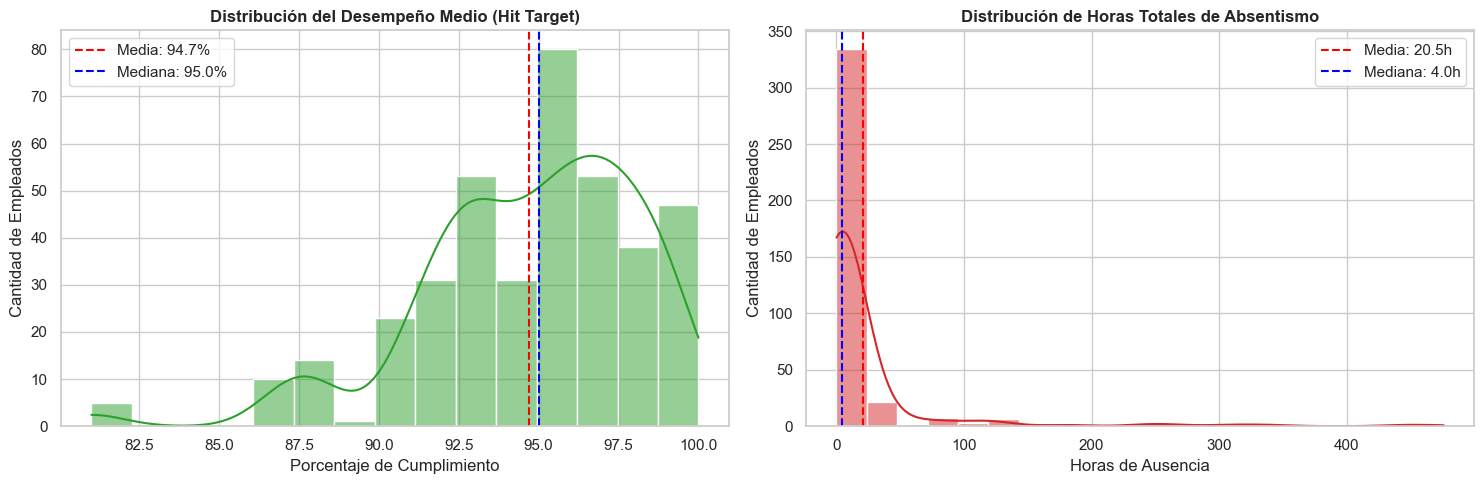

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 🔹 Hit Target
sns.histplot(df_perfil['Hit_target'], kde=True, bins=15, color='#2ca02c', ax=axes[0])
axes[0].set_title('Distribución del Desempeño Medio (Hit Target)', fontweight='bold')
axes[0].set_xlabel('Porcentaje de Cumplimiento')
axes[0].set_ylabel('Cantidad de Empleados')

media_hit = df_perfil['Hit_target'].mean()
mediana_hit = df_perfil['Hit_target'].median()

axes[0].axvline(media_hit, color='red', linestyle='--', label=f"Media: {media_hit:.1f}%")
axes[0].axvline(mediana_hit, color='blue', linestyle='--', label=f"Mediana: {mediana_hit:.1f}%")
axes[0].legend()

# 🔹 Absenteeism
sns.histplot(df_perfil['Absenteeism_hours'], kde=True, bins=20, color='#d62728', ax=axes[1])
axes[1].set_title('Distribución de Horas Totales de Absentismo', fontweight='bold')
axes[1].set_xlabel('Horas de Ausencia')
axes[1].set_ylabel('Cantidad de Empleados')

media_abs = df_perfil['Absenteeism_hours'].mean()
mediana_abs = df_perfil['Absenteeism_hours'].median()

axes[1].axvline(media_abs, color='red', linestyle='--', label=f"Media: {media_abs:.1f}h")
axes[1].axvline(mediana_abs, color='blue', linestyle='--', label=f"Mediana: {mediana_abs:.1f}h")
axes[1].legend()

plt.tight_layout()
plt.show()

## Matriz de Relaciones: ¿Qué variables impactan en la empresa?
Generamos una matriz de correlación de Pearson para evaluar matemáticamente la fuerza de las relaciones entre las variables sociodemográficas y nuestros KPIs. 

A continuación, extraemos dos **rankings de correlación** directos: uno para ver qué impulsa el desempeño y otro para ver qué detona el absentismo.



RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (HIT TARGET)


,Hit_target
Education,0.124709
Social_smoker,0.019574
Absenteeism_hours,0.005713
Service_time,0.002184
Work_load_Average_day,0.001699
Disciplinary_failure,-0.016725
Son,-0.040919
Age,-0.051587
Body_mass_index,-0.052359
Distance_Residence_Work,-0.083654



--------------------------------------------------------

RANKING: FACTORES ASOCIADOS AL ABSENTISMO


,Absenteeism_hours
Son,0.081875
Social_drinker,0.060620
Work_load_Average_day,0.038837
Age,0.022876
Service_time,0.018602
Hit_target,0.005713
Transportation_expense,-0.009593
Social_smoker,-0.010212
Body_mass_index,-0.032729
Education,-0.044992


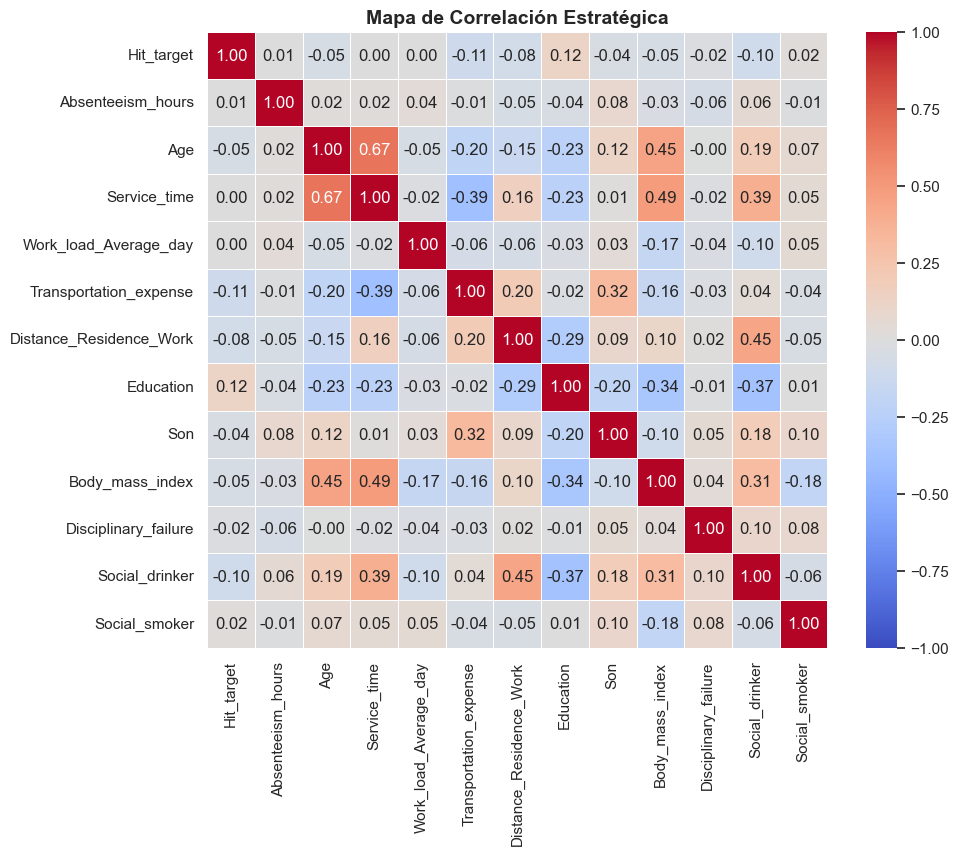

In [50]:
# Seleccionamos las variables relevantes
columnas_estudio = ['Hit_target', 'Absenteeism_hours', 'Age', 'Service_time', 'Work_load_Average_day', 'Transportation_expense',
                    'Distance_Residence_Work', 'Education', 'Son', 'Body_mass_index', 'Disciplinary_failure', 'Social_drinker', 'Social_smoker']

matriz_corr = df_perfil[columnas_estudio].corr()

# Ranking para Desempeño (Hit Target)
ranking_desempeno = matriz_corr[['Hit_target']].sort_values(by='Hit_target', ascending=False)
print("RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (HIT TARGET)")
display(ranking_desempeno.iloc[1:]) # Omitimos la correlación consigo misma

print("\n--------------------------------------------------------\n")

# Ranking para Absentismo
ranking_absentismo = matriz_corr[['Absenteeism_hours']].sort_values(by='Absenteeism_hours', ascending=False)
print("RANKING: FACTORES ASOCIADOS AL ABSENTISMO")
display(ranking_absentismo.iloc[1:])

# Mapa de calor de la matriz completa
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Correlación Estratégica', fontsize=14, fontweight='bold')
plt.show()

## Matriz de Relación de Spearman: ¿Qué variables impactan en la empresa?
Como las distribuciones no son normales, tambien hemos evaluado la matriz de correlación de Spearman porque resulta más robusta paracuando las distribuciones no son normales y la presncia de outliers es muy importante (como reuslta en el caso de horas de absentismo). A continuación, extraemos dos **rankings de correlación** directos: uno para ver qué impulsa el desempeño y otro para ver qué detona el absentismo.

In [51]:
# Usamos el método 'spearman' para capturar relaciones no lineales y tratar variables ordinales
matriz_corr_spearman = df_perfil[['Hit_target', 'Absenteeism_hours', 'Work_load_Average_day', 'Service_time', 'Transportation_expense', 'Education', 'Son', 'Age', 'Body_mass_index', 
                                  'Distance_Residence_Work', 'Disciplinary_failure', 'Social_drinker', 'Social_smoker']].corr(method='spearman')

print("RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (Método Spearman - Más preciso para este dataset)")
ranking_hp = matriz_corr_spearman['Hit_target'].sort_values(ascending=False).drop('Hit_target')
display(ranking_hp)

print("\n--------------------------------------------------------\n")

print("RANKING: FACTORES ASOCIADOS AL ABSENTISMO (Método Spearman - Más preciso para este dataset)")
ranking_ab = matriz_corr_spearman['Absenteeism_hours'].sort_values(ascending=False).drop('Absenteeism_hours')
display(ranking_ab)

RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (Método Spearman - Más preciso para este dataset)


Education                  0.148163
Service_time               0.035591
Absenteeism_hours          0.022767
Social_smoker              0.011739
Disciplinary_failure       0.010386
Body_mass_index           -0.022561
Work_load_Average_day     -0.039110
Son                       -0.049762
Social_drinker            -0.053662
Age                       -0.063227
Distance_Residence_Work   -0.077644
Transportation_expense    -0.141396
Name: Hit_target, dtype: float64


--------------------------------------------------------

RANKING: FACTORES ASOCIADOS AL ABSENTISMO (Método Spearman - Más preciso para este dataset)


Transportation_expense     0.197350
Son                        0.136413
Social_smoker              0.064827
Work_load_Average_day      0.042053
Education                  0.029228
Social_drinker             0.028276
Hit_target                 0.022767
Distance_Residence_Work   -0.019903
Service_time              -0.104051
Age                       -0.115716
Body_mass_index           -0.121981
Disciplinary_failure      -0.288574
Name: Absenteeism_hours, dtype: float64

### Nota Metodológica: Uso de Correlación de Spearman
Para este análisis hemos optado por la **Correlación de Spearman** en lugar de Pearson. Dado que contamos con variables ordinales (`Education`, `Son`) y relaciones que no necesariamente siguen una línea recta perfecta, Spearman nos ofrece una visión más realista basada en el orden jerárquico de los datos, siendo menos sensible a valores extremos y capturando tendencias monótonas con mayor precisión.

## Mapa de Correlación de Spearman (Análisis No Lineal)
Para validar de forma global las relaciones entre variables, generamos este mapa de calor utilizando el coeficiente de **Spearman**. A diferencia de Pearson, este método resulta más adecuado en presencia de nuestras variables ordinales (Educación, Hijos) y captura mejor las tendencias de comportamiento que no son estrictamente proporcionales, ofreciendo una radiografía más precisa del ecosistema de la empresa.

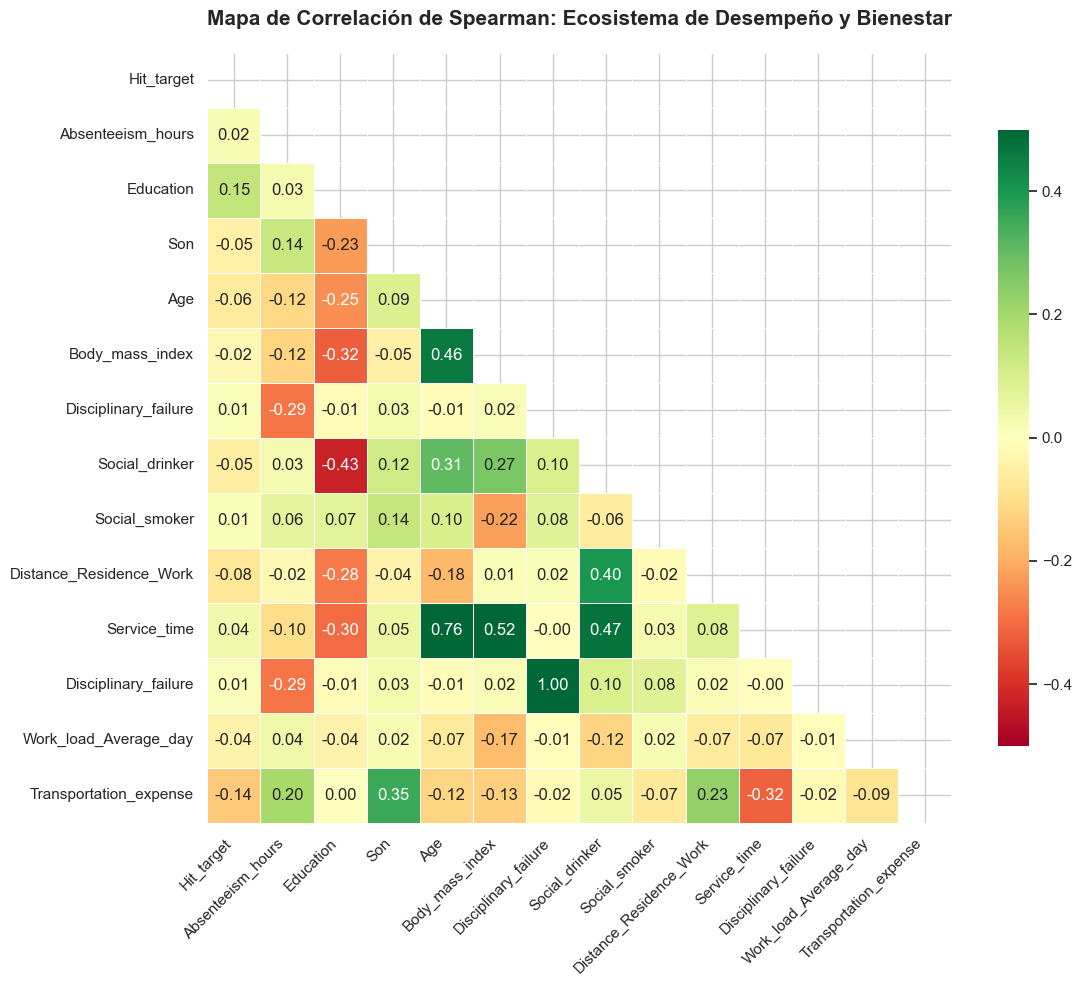

In [52]:
# Definimos las variables que queremos cruzar
columnas_finales = ['Hit_target', 'Absenteeism_hours', 'Education', 'Son', 'Age', 'Body_mass_index', 'Disciplinary_failure', 'Social_drinker', 'Social_smoker',
                    'Distance_Residence_Work', 'Service_time','Disciplinary_failure', 'Work_load_Average_day', 'Transportation_expense']

# Calculamos la matriz con el método Spearman
matriz_spearman = df_perfil[columnas_finales].corr(method='spearman')

# Visualización del Mapa de Calor
plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(matriz_spearman, dtype=bool)) # Máscara para ver solo la mitad inferior (evita duplicados)

sns.heatmap(matriz_spearman, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', 
            vmin=-0.5, vmax=0.5, # Ajustamos límites para que se vean los matices
            center=0, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Mapa de Correlación de Spearman: Ecosistema de Desempeño y Bienestar', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

## Detección Visual

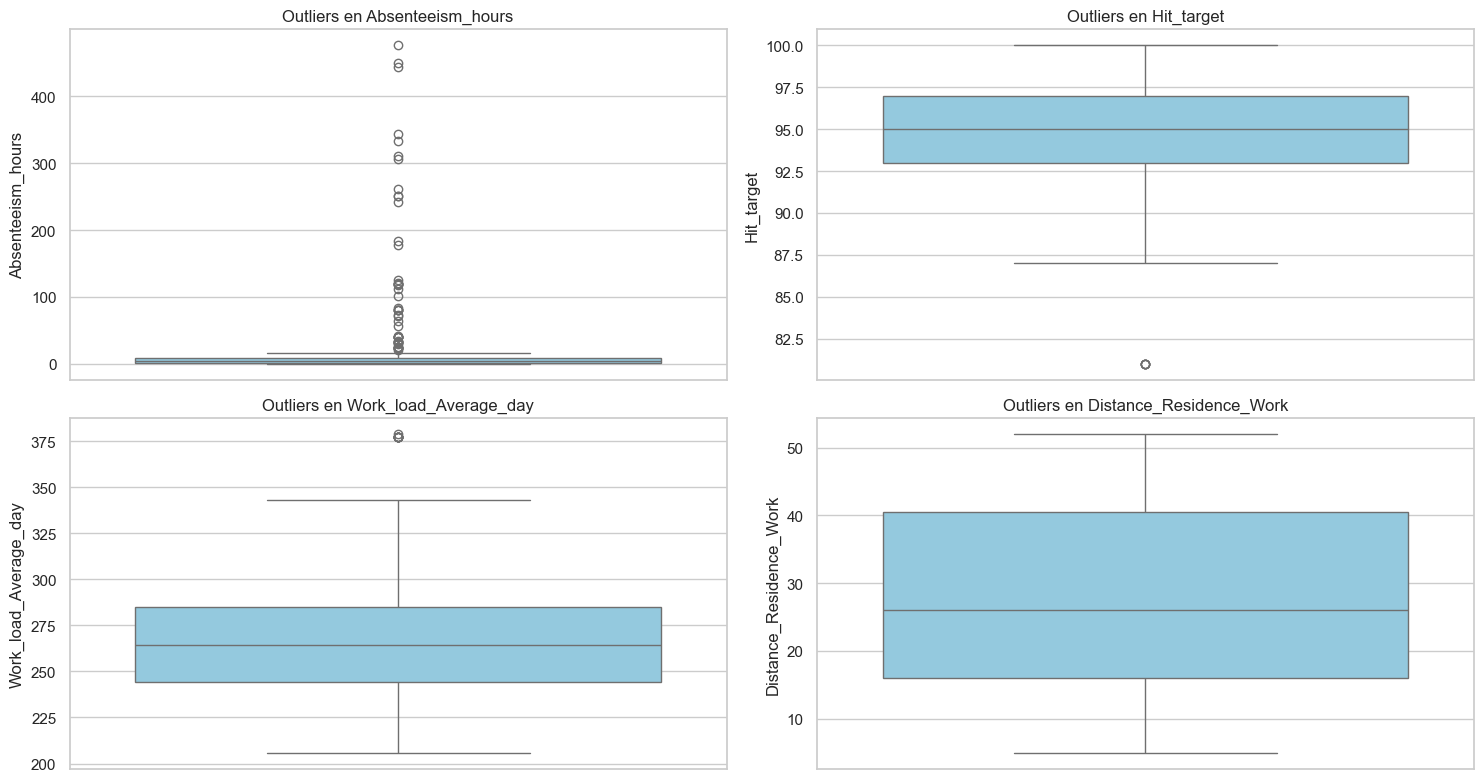

In [53]:
# Variables numéricas donde buscar outliers
vars_numericas = ['Absenteeism_hours', 'Hit_target', 'Work_load_Average_day', 'Distance_Residence_Work']

plt.figure(figsize=(15, 8))

# Creamos un gráfico de caja para cada variable
for i, var in enumerate(vars_numericas):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df_perfil[var], color='skyblue')
    plt.title(f'Outliers en {var}')

plt.tight_layout()
plt.show()

## Detección Estadística (El método del Rango Intercuartílico - IQR)
Para saber exactamente cuántos outliers hay y no solo ver "puntos en un dibujo", usamos la regla del IQR. Es lo que usa Seaborn por detrás para dibujar los bigotes.

In [54]:
def contar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    return len(outliers), limite_inferior, limite_superior

# Probamos con Absentismo, que parece ser la variable con más ruido
n_outliers, inf, sup = contar_outliers(df_perfil, 'Absenteeism_hours')
print(f"En 'Absenteeism_hours' hay {n_outliers} valores fuera del rango [{inf:.2f}, {sup:.2f}]")

En 'Absenteeism_hours' hay 53 valores fuera del rango [-7.00, 17.00]


## Profundización Analítica: Los Verdaderos Impulsores del Negocio

En general, observamos que las correlaciones en nuestra plantilla actual son muy débiles.  
Esto sugiere que el desempeño y el absentismo son multicausales. 
Vamos a analizar los factores que, aunque con una fuerza moderada, lideran las tendencias de nuestra empresa:  
- Desempeño: antiguedad, carga laboral diaria y distancia al trabajo
- Absentismo: bebedor social, fumador social y faltas disciplinarias


### Insight 1: La Antiguedad no es el Principal Motor del Desempeño

### Insight 2: Las Sanciones disciplinarias son el principal motor de Presencialidad


Si representamos el desempeño frente a la antiguedad y el absentismo  frente a las sanciones disciplinarias 

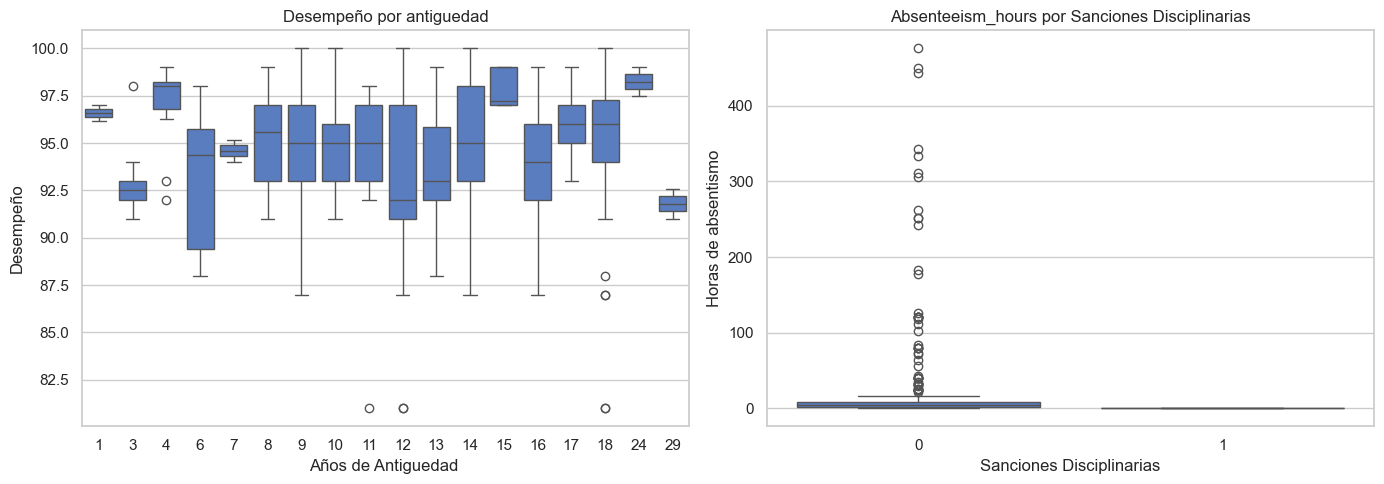

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Primer gráfico
sns.boxplot(data=df_perfil, x='Service_time', y='Hit_target', ax=axes[0])
axes[0].set_title('Desempeño por antiguedad')
axes[0].set_xlabel('Años de Antiguedad ')
axes[0].set_ylabel('Desempeño')

# Segundo gráfico
sns.boxplot(data=df_perfil, x='Disciplinary_failure', y='Absenteeism_hours', ax=axes[1])
axes[1].set_title('Absenteeism_hours por Sanciones Disciplinarias')
axes[1].set_xlabel('Sanciones Disciplinarias')
axes[1].set_ylabel('Horas de absentismo')

plt.tight_layout()
plt.show()

### Insight 3: Impacto de actividad social (alcohol/tabaco) y de las sanciones disciplinarias en el absentismo
Los datos revelan una dualidad interesante: .

En el caso del alcohol, se observa que los empleados que consumen de forma social presentan un mayor número de horas de ausencia.   

Sin embargo, el tabaco no muestra una relación clara, ya que los no fumadores incluso registran ligeramente más absentismo.  

Por otro lado, las sanciones disciplinarias presentan un comportamiento anómalo, ya que el grupo sancionado muestra ausencia nula, lo que podría indicar un problema en los datos. En general, el alcohol parece ser el factor más asociado al incremento del absentismo en este conjunto de datos.

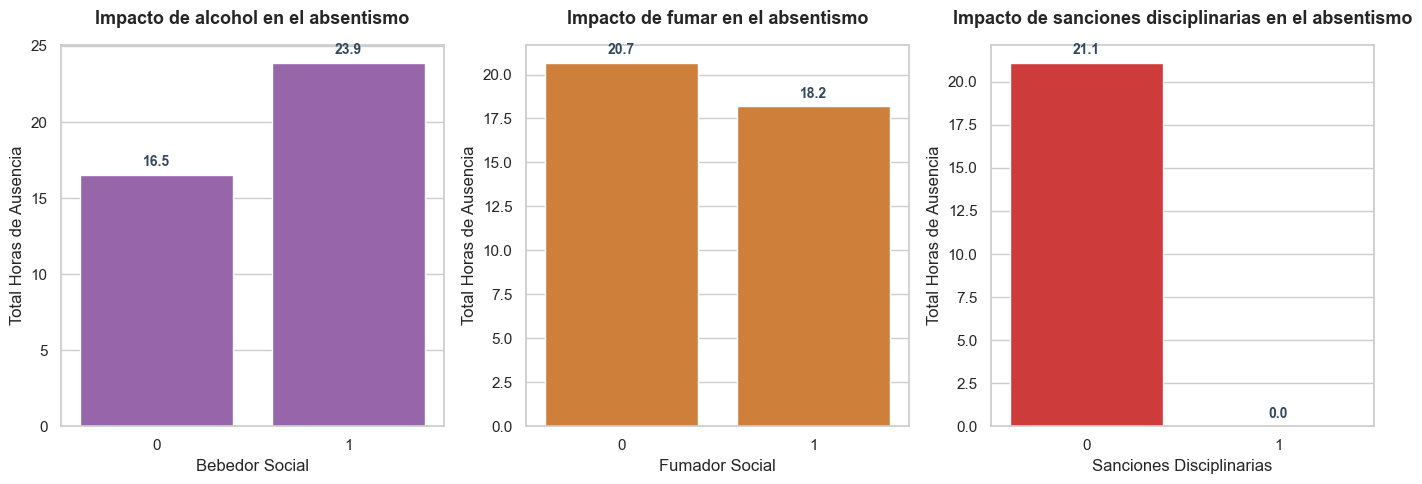

In [56]:
# Configuramos la figura con colores diferenciados: Púrpura (Alcohol) y Naranja (Tabaco)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Gráfico A: Impacto Alcohol en el Absentismo (Color Púrpura)
sns.barplot(data=df_perfil, x='Social_drinker', y='Absenteeism_hours', color='#9b59b6', ci=None, ax=axes[0])
axes[0].set_title('Impacto de alcohol en el absentismo', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Bebedor Social')
axes[0].set_ylabel('Total Horas de Ausencia')


# Gráfico B: Impacto Tabaco en el Absentismo (Color Naranja)
sns.barplot(data=df_perfil, x='Social_smoker', y='Absenteeism_hours', color='#e67e22', ci=None, ax=axes[1])
axes[1].set_title('Impacto de fumar en el absentismo', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Fumador Social')
axes[1].set_ylabel('Total Horas de Ausencia')

# Gráfico C: Impacto Sanciones Disciplinarias en el Absentismo (Color Naranja)
sns.barplot(data=df_perfil, x='Disciplinary_failure', y='Absenteeism_hours', color="#e62222", ci=None, ax=axes[2])
axes[2].set_title('Impacto de sanciones disciplinarias en el absentismo', fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('Sanciones Disciplinarias')
axes[2].set_ylabel('Total Horas de Ausencia')

# Añadimos etiquetas de valor sobre las barras para evitar el esfuerzo de lectura
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#34495e')

plt.tight_layout()
plt.show()

### Insight 4: Carga de trabajo media diaria y Tiempo de Servicio
Contrario a lo que se podría esperar, en este dataset tanto la carga de trabajo media diaria (-0.04) como el tiempo de servicio (0.04) muestran una relación prácticamente nula con el desempeño, con efectos muy leves en direcciones opuestas. Esto sugiere que estas variables por sí solas no explican significativamente la variabilidad del rendimiento.  
Al reperesentar el desempeño por grupos de edad, tanto el análisis de regresión como la segmentación por grupos muestran que la antigüedad no tiene un impacto significativo en el desempeño. La estabilidad de las medianas y la ausencia de tendencia sugieren que el rendimiento se mantiene relativamente constante independientemente de los años de experiencia.

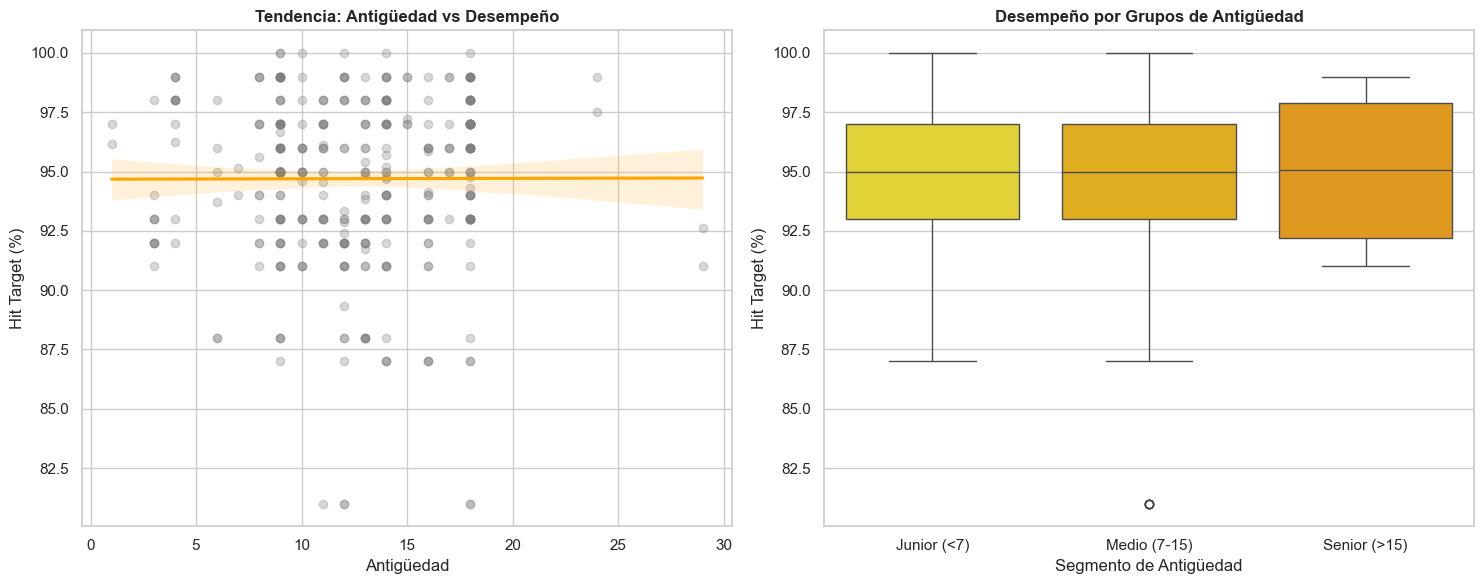

In [57]:
# Primero creamos grupos de antiguedad para segmentar el análisis de forma diferente a la anterior
df_perfil['Service_time_Group'] = pd.cut(df_perfil['Service_time'], 
                                bins=[0, 10, 20, 30], 
                                labels=['Junior (<7)', 'Medio (7-15)', 'Senior (>15)'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Regresión lineal clásica 
sns.regplot(data=df_perfil, x='Service_time', y='Hit_target', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'orange'})
axes[0].set_title('Tendencia: Antigüedad vs Desempeño', fontweight='bold')
axes[0].set_xlabel('Antigüedad')
axes[0].set_ylabel('Hit Target (%)')

# Análisis por Segmentos
sns.boxplot(data=df_perfil, x='Service_time_Group', y='Hit_target', palette='Wistia', ax=axes[1])
axes[1].set_title('Desempeño por Grupos de Antigüedad', fontweight='bold')
axes[1].set_xlabel('Segmento de Antigüedad')
axes[1].set_ylabel('Hit Target (%)')

plt.tight_layout()
plt.show()

## Representación Visual de la relación entre Absentismo y Desempeño  

A nivel de cada individuo podemos representar la relación entre las horas de absentismo y su nivel de desempeño y también se observa que  la relación es prácticamente nula o muy débil. La linea de tendencia es casi horizontal con ligera pendiente positiva por lo que el absentismo no parece afectar al desempeño. La mayor concentración de absentismo se concentra entre 0-50 horas y el rendimiento entre 93-98%, lo que indica que la mayoria de los empleados tiene bajo absentismo y el desempeño bastante estable y alto.

La alta dispersión vertical (entre 88-100%) indica que existen otros valores que afectan al desempeño diferentes del absentismo

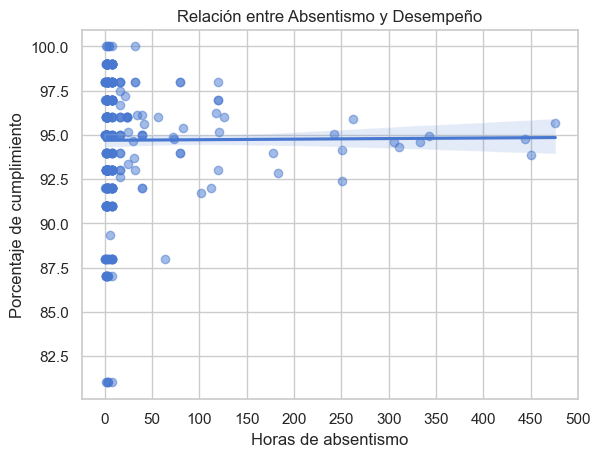

In [58]:
sns.regplot(x='Absenteeism_hours',y='Hit_target',data=df_perfil,scatter_kws={'alpha': 0.5})

plt.xlabel('Horas de absentismo')
plt.ylabel('Porcentaje de cumplimiento')
plt.title('Relación entre Absentismo y Desempeño')
max_val = df_perfil['Absenteeism_hours'].max()
plt.xticks(np.arange(0, max_val + 50, 50))
plt.show()

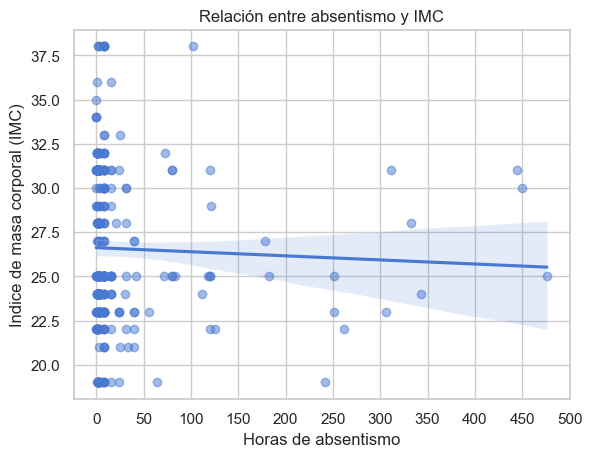

In [59]:
sns.regplot(x='Absenteeism_hours',y='Body_mass_index',data=df_perfil,scatter_kws={'alpha': 0.5})

plt.xlabel('Horas de absentismo')
plt.ylabel('Indice de masa corporal (IMC)')
plt.title('Relación entre absentismo y IMC')
max_val = df_perfil['Absenteeism_hours'].max()
plt.xticks(np.arange(0, max_val + 50, 50))
plt.show()

## Representación Visual de la relación entre Absentismo/Desempeño y Sanciones disciplinarias

In [60]:
df_perfil['Disciplinary_failure'] = pd.to_numeric(
    df_perfil['Disciplinary_failure'],
    errors='coerce'
)

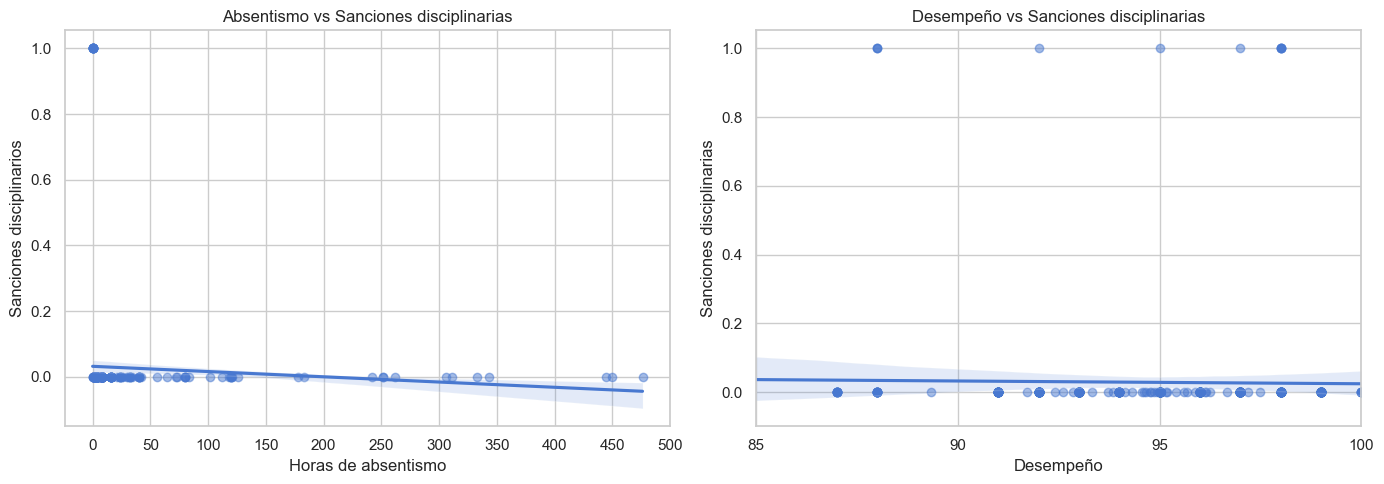

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Absentismo vs Tiempo de servicio ---
sns.regplot(x='Absenteeism_hours', y='Disciplinary_failure', data=df_perfil, scatter_kws={'alpha': 0.5}, ax=axes[0])
           
axes[0].set_xlabel('Horas de absentismo')
axes[0].set_ylabel('Sanciones disciplinarios')
axes[0].set_title('Absentismo vs Sanciones disciplinarias')

max_val_1 = df_perfil['Absenteeism_hours'].max()
axes[0].set_xticks(np.arange(0, max_val_1 + 50, 50))

# --- Gráfico 2: Desempeño vs Tiempo de servicio ---
sns.regplot(x='Hit_target', y='Disciplinary_failure', data=df_perfil, scatter_kws={'alpha': 0.5}, ax=axes[1])

axes[1].set_xlabel('Desempeño')
axes[1].set_ylabel('Sanciones disciplinarias')
axes[1].set_title('Desempeño vs Sanciones disciplinarias')

# 👇 limitar eje X entre 80 y 100
axes[1].set_xlim(85, 100)
axes[1].set_xticks(np.arange(85, 101, 5))

plt.tight_layout()
plt.show()

## Representación Visual de la relación entre Absentismo/Desempeño y Antiguedad

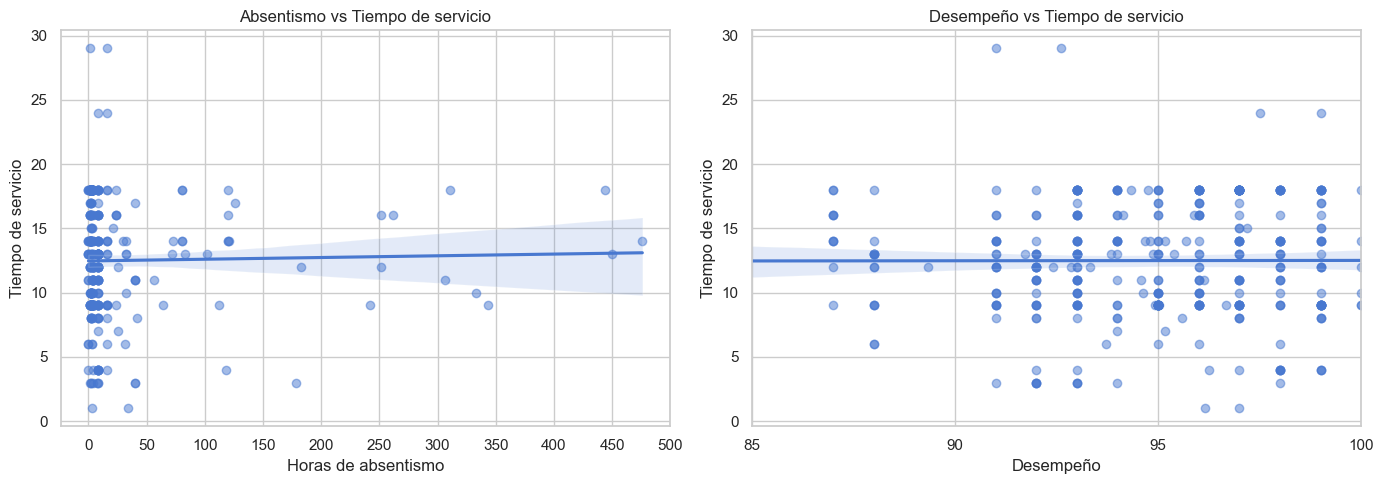

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Absentismo vs Tiempo de servicio ---
sns.regplot(x='Absenteeism_hours', y='Service_time', data=df_perfil, scatter_kws={'alpha': 0.5}, ax=axes[0])
           
axes[0].set_xlabel('Horas de absentismo')
axes[0].set_ylabel('Tiempo de servicio')
axes[0].set_title('Absentismo vs Tiempo de servicio')

max_val_1 = df_perfil['Absenteeism_hours'].max()
axes[0].set_xticks(np.arange(0, max_val_1 + 50, 50))

# --- Gráfico 2: Desempeño vs Tiempo de servicio ---
sns.regplot(x='Hit_target', y='Service_time', data=df_perfil, scatter_kws={'alpha': 0.5}, ax=axes[1])

axes[1].set_xlabel('Desempeño')
axes[1].set_ylabel('Tiempo de servicio')
axes[1].set_title('Desempeño vs Tiempo de servicio')

# 👇 limitar eje X entre 80 y 100
axes[1].set_xlim(85, 100)
axes[1].set_xticks(np.arange(85, 101, 5))

plt.tight_layout()
plt.show()

## Análisis de Interconexión: ¿Cuál es el motor del sistema?
Más allá de ver cómo afectan las variables al `Hit_target`, este análisis de **suma de correlaciones absolutas** nos permite identificar qué variable es la más "influyente" en todo el ecosistema de la empresa. Una puntuación alta indica una variable que está conectada con casi todos los demás factores (salud, logística, familia y rendimiento).

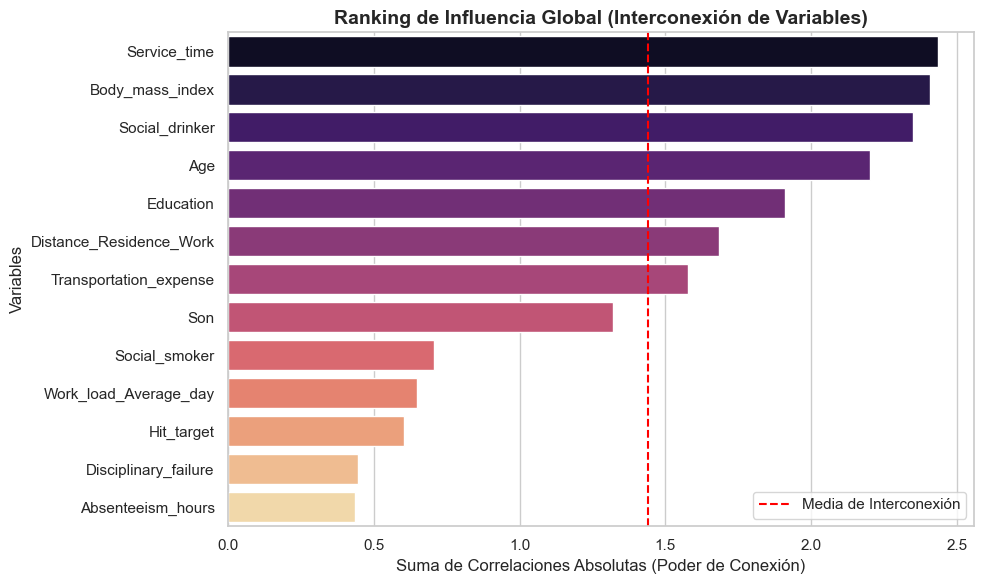

La variable más 'conectada' en la empresa es: Service_time


In [63]:
# Calculamos la matriz de correlaciones absolutas (para que los negativos no resten)
abs_corr_matrix = matriz_corr.abs()

# Sumamos las correlaciones de cada variable (restando 1 de su propia correlación consigo misma)
variable_influence = abs_corr_matrix.sum() - 1
variable_influence = variable_influence.sort_values(ascending=False)

# Visualización del Ranking de Influencia Global
plt.figure(figsize=(10, 6))
sns.barplot(x=variable_influence.values, y=variable_influence.index, palette='magma')
plt.title('Ranking de Influencia Global (Interconexión de Variables)', fontsize=14, fontweight='bold')
plt.xlabel('Suma de Correlaciones Absolutas (Poder de Conexión)')
plt.ylabel('Variables')

# Añadimos una línea que marque la variable "Pivote"
plt.axvline(variable_influence.mean(), color='red', linestyle='--', label='Media de Interconexión')
plt.legend()

plt.tight_layout()
plt.show()

print("La variable más 'conectada' en la empresa es:", variable_influence.index[0])

Edad, Antiguedad y IMC son las mas correlacionadas, pero el resultado es idéntico cuando tenemos en cuenta la media de la correlación en lugar de la suma para evitar que las variables mas relacionadas artificialmente "ganen"

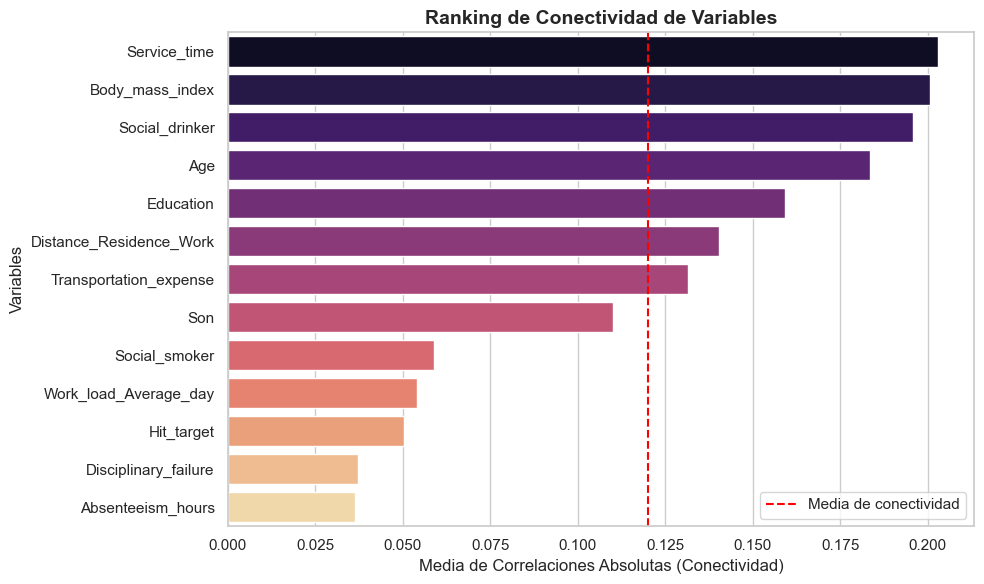

La variable más conectada es: Service_time


In [64]:
# Matriz de correlación absoluta
abs_corr_matrix = matriz_corr.abs()

# Eliminamos la diagonal (autocorrelación = 1)
np.fill_diagonal(abs_corr_matrix.values, np.nan)

# Calculamos la media de correlaciones con otras variables
variable_influence = abs_corr_matrix.mean()
variable_influence = variable_influence.sort_values(ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=variable_influence.values, y=variable_influence.index, palette='magma')

plt.title('Ranking de Conectividad de Variables', fontsize=14, fontweight='bold')
plt.xlabel('Media de Correlaciones Absolutas (Conectividad)')
plt.ylabel('Variables')

# Línea de referencia (media global)
plt.axvline(variable_influence.mean(), color='red', linestyle='--', label='Media de conectividad')
plt.legend()

plt.tight_layout()
plt.show()

print("La variable más conectada es:", variable_influence.index[0])

## Mapa de Centralidad de Riesgo (Bienestar Laboral)
Este ranking no mide solo cuánto afecta una variable al absentismo, sino qué variable es el **"punto de unión"** de todos los factores de riesgo (Salud, Edad, Carga Familiar y Logística). Identificar esta variable nos permite saber dónde una pequeña intervención de bienestar tendrá el mayor impacto sistémico en la reducción de ausencias.

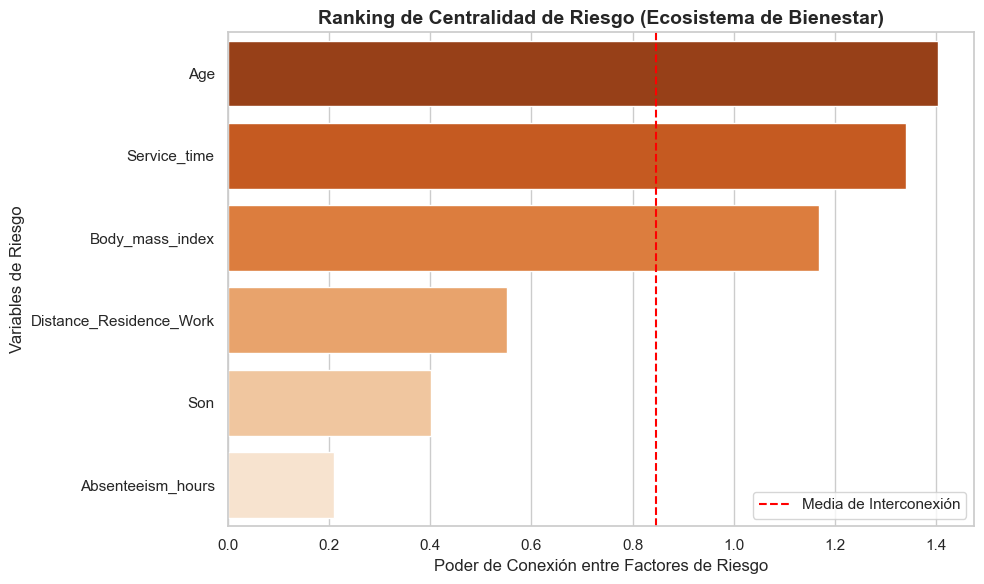

La variable 'Pivote' para el bienestar es: Age


In [65]:
# Seleccionamos las variables que componen el ecosistema de bienestar y riesgo
vars_riesgo = ['Absenteeism_hours', 'Body_mass_index', 'Age', 'Son', 
               'Distance_Residence_Work', 'Service_time']

# Calculamos la matriz de interconexión (en valor absoluto)
matriz_bienestar = df_perfil[vars_riesgo].corr().abs()

# Sumamos las relaciones de cada factor dentro de este ecosistema de riesgo
centralidad_riesgo = matriz_bienestar.sum() - 1
centralidad_riesgo = centralidad_riesgo.sort_values(ascending=False)

# Visualización: ¿Cuál es el núcleo del absentismo?
plt.figure(figsize=(10, 6))
sns.barplot(x=centralidad_riesgo.values, y=centralidad_riesgo.index, palette='Oranges_r')
plt.title('Ranking de Centralidad de Riesgo (Ecosistema de Bienestar)', fontsize=14, fontweight='bold')
plt.xlabel('Poder de Conexión entre Factores de Riesgo')
plt.ylabel('Variables de Riesgo')

# Añadimos una línea que marque la variable "Pivote"
plt.axvline(centralidad_riesgo.mean(), color='red', linestyle='--', label='Media de Interconexión')
plt.legend()

plt.tight_layout()
plt.show()

print(f"La variable 'Pivote' para el bienestar es: {centralidad_riesgo.index[0]}")